In [1]:
# Stock Price Prediction (Short-Term)

## Objective
The goal of this task is to predict the next day's closing price of a stock using historical data such as Open, High, Low, and Volume.
We use regression models to learn patterns from past data and evaluate how accurately we can predict future prices.

SyntaxError: unterminated string literal (detected at line 4) (3774344959.py, line 4)

In [5]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import accuracy_score

In [7]:
# SELECTED THE APPLE STOCKS
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400520,72.460784,71.156682,71.409785,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085114,73.386431,71.631559,71.631559,132079200


In [8]:
# CREATED TARGET COLUMN
stock["Target"] = stock["Close"].shift(-1)
# DROPED LAST COLOUMN BECUSE OF NAN VALUE
stock = stock.dropna()
# FEATURES AND TARGET AS GIVEN
X = stock[["Open", "High", "Low", "Volume"]]
y = stock["Target"]

In [9]:
# DATASET IS SPLITED INTO TRAIN/TEST SPLIT SO WE CAN TRAIN MODEL THEN TEST IT 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [10]:
# TRAINED THE MODEL MODEL USED LINEARREGRESSION
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [15]:
# USED THE DATASET LEFT FOR TESTING
y_pred = model.predict(X_test)

In [17]:
# EVELUATED THE METRICS
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.6542226165197371


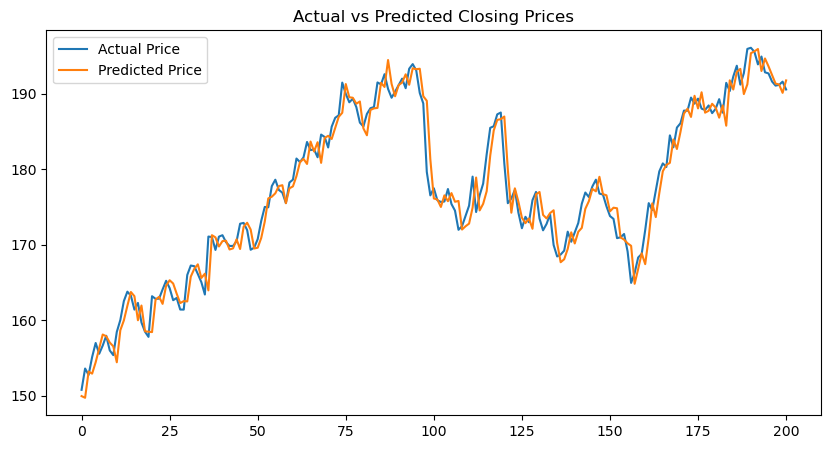

In [19]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(y_pred, label="Predicted Price")
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()

In [23]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.9579012111569295


In [ ]:
## Results & Insights

- The Linear Regression model was able to predict stock prices with reasonable accuracy.
- Mean Absolute Error indicates the average difference between actual and predicted values.
- Random Forest performed better due to capturing non-linear relationships.
- Stock prices are influenced by multiple factors, so predictions are approximate.